In [1]:
import uproot
import awkward as ak
import numpy as np
import pandas as pd
import zfit
import matplotlib.pyplot as plt
import mplhep as hep
from hepstats.splot import compute_sweights

/home/tandrade/.local/lib/python3.9/site-packages/zfit/__init__.py:63: UserWarning: TensorFlow warnings are by default suppressed by zfit. In order to show them, set the environment variable ZFIT_DISABLE_TF_WARNINGS=0. In order to suppress the TensorFlow warnings AND this warning, set ZFIT_DISABLE_TF_WARNINGS=1.
  warnings.warn(


In [2]:
plt.style.use(hep.style.CMS)

In [3]:
features_raw = [
    "BToTrkTrkMuMu_fit_l1_pt_good", "BToTrkTrkMuMu_fit_l2_pt_good",
    "BToTrkTrkMuMu_fit_trk1_pt_good", "BToTrkTrkMuMu_fit_trk2_pt_good",
    "BToTrkTrkMuMu_fit_eta_good", "BToTrkTrkMuMu_fit_cos2D_good",
    "BToTrkTrkMuMu_trk1_dca_good", "BToTrkTrkMuMu_trk1_dcaErr_good",
    "BToTrkTrkMuMu_trk2_dca_good", "BToTrkTrkMuMu_trk2_dcaErr_good",
    # ADD THESE MISSING ONES:
    "BToTrkTrkMuMu_fit_pt_good", 
    "BToTrkTrkMuMu_fit_phi_good", 
    "BToTrkTrkMuMu_svprob_good",
    "MuMu_pt_good", 
    "MuMu_eta_good", 
    "MuMu_phi_good",
    "BToTrkTrkMuMu_fit_ditrack_mass_Kpi_good"
]
cols_sel = ["BToTrkTrkMuMu_fit_mass_Kpi_good", "MuMu_mass_good", "HLT_DoubleMu4_3_LowMass"]

In [4]:
def load_data_clean(path):
    with uproot.open(path) as f:
        df = ak.to_dataframe(f["tree_ML"].arrays(features_raw + cols_sel, library="ak"))    
    mask = (df['BToTrkTrkMuMu_fit_mass_Kpi_good'] > 5.0) & (df['BToTrkTrkMuMu_fit_mass_Kpi_good'] < 5.6) & \
           (df['MuMu_mass_good'] > 3.3) & (df['MuMu_mass_good'] < 4.05) & (df['HLT_DoubleMu4_3_LowMass'] == 1)
    return df[mask].copy()

df_data = load_data_clean("/home/tandrade/Flavour_Anomalies/Data/final_data_skim.root")
df_mc = load_data_clean("/home/tandrade/Flavour_Anomalies/Data/final_mc_psi2s_skim.root")

In [12]:
df_data.keys()

Index(['BToTrkTrkMuMu_fit_l1_pt_good', 'BToTrkTrkMuMu_fit_l2_pt_good',
       'BToTrkTrkMuMu_fit_trk1_pt_good', 'BToTrkTrkMuMu_fit_trk2_pt_good',
       'BToTrkTrkMuMu_fit_eta_good', 'BToTrkTrkMuMu_fit_cos2D_good',
       'BToTrkTrkMuMu_trk1_dca_good', 'BToTrkTrkMuMu_trk1_dcaErr_good',
       'BToTrkTrkMuMu_trk2_dca_good', 'BToTrkTrkMuMu_trk2_dcaErr_good',
       'BToTrkTrkMuMu_fit_pt_good', 'BToTrkTrkMuMu_fit_phi_good',
       'BToTrkTrkMuMu_svprob_good', 'MuMu_pt_good', 'MuMu_eta_good',
       'MuMu_phi_good', 'BToTrkTrkMuMu_fit_ditrack_mass_Kpi_good',
       'BToTrkTrkMuMu_fit_mass_Kpi_good', 'MuMu_mass_good',
       'HLT_DoubleMu4_3_LowMass', 'sweight_sig'],
      dtype='object')

In [5]:
obs = zfit.Space("BToTrkTrkMuMu_fit_mass_Kpi_good", limits = (5.0, 5.6))
data_zfit = zfit.Data.from_pandas(df_data["BToTrkTrkMuMu_fit_mass_Kpi_good"], obs=obs)

In [6]:
mu    = zfit.Parameter("mu", 5.28, 5.15, 5.40) 
sigma = zfit.Parameter("sigma", 0.025, 0.005, 0.100)
alpha = zfit.Parameter("alpha", 1.5, 0.1, 5.0)
n     = zfit.Parameter("n", 5.0, 0.1, 20.0)
tau   = zfit.Parameter("tau", -2.0, -10.0, 0.0)

total_ev = len(df_data)
n_sig = zfit.Parameter("n_sig", total_ev * 0.1, 0, total_ev) 
n_bkg = zfit.Parameter("n_bkg", total_ev * 0.9, 0, total_ev)

signal_pdf_base = zfit.pdf.CrystalBall(mu=mu, sigma=sigma, alpha=alpha, n=n, obs=obs)
bkg_pdf_base    = zfit.pdf.Exponential(lambda_=tau, obs=obs)

signal_ext = signal_pdf_base.create_extended(n_sig)
bkg_ext    = bkg_pdf_base.create_extended(n_bkg)

model = zfit.pdf.SumPDF([signal_ext, bkg_ext])

In [7]:
nll = zfit.loss.ExtendedUnbinnedNLL(model, data_zfit)

minimizer = zfit.minimize.Minuit(tol=1e-3) 
result = minimizer.minimize(nll)

print(f"Status do Fit: {'VÁLIDO ✅' if result.valid else 'FALHOU ❌'}")
print(result)

if result.valid:
    try:
        result.hesse() # Calcula erros
        print(">>> Erros calculados (Hesse).")
    except Exception as e:
        print(f">>> Aviso: Hesse falhou ({e}), mas o fit convergiu.")

Status do Fit: VÁLIDO ✅
FitResult of
<ExtendedUnbinnedNLL model=[<zfit.<class 'zfit.models.functor.SumPDF'>  params=[Composed_autoparam_1, Composed_autoparam_2]] data=[<zfit.Data: Data obs=('BToTrkTrkMuMu_fit_mass_Kpi_good',) shape=(206730, 1)>] constraints=[]> 
with
<Minuit Minuit tol=0.001>

╒═════════╤═════════════╤══════════════════╤═════════╤══════════════════════════════╕
│  valid  │  converged  │  param at limit  │   edm   │   approx. fmin (full | opt.) │
╞═════════╪═════════════╪══════════════════╪═════════╪══════════════════════════════╡
│  True   │    True     │      False       │ 0.00011 │       -110351.71 |  6461.542 │
╘═════════╧═════════════╧══════════════════╧═════════╧══════════════════════════════╛

Parameters
name      value  (rounded)    at limit
------  ------------------  ----------
n_sig              8256.91       False
n_bkg               198473       False
mu                 5.27394       False
sigma            0.0298597       False
alpha             0.979201   

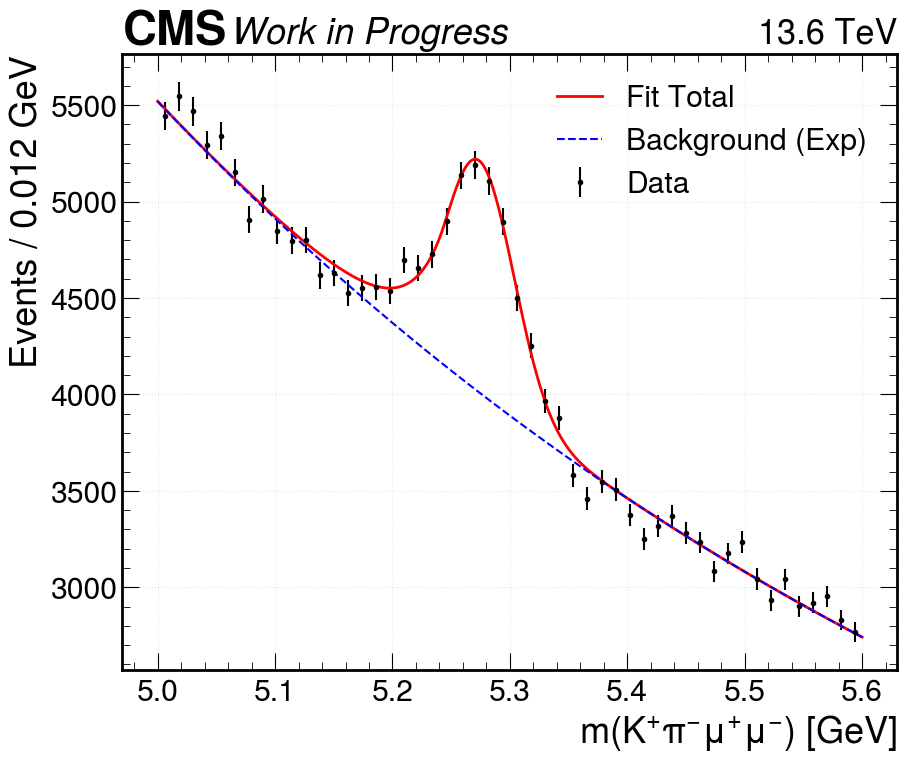

In [8]:
def plot_fit_results(data, model, obs, title="Fit Result"):
    plt.figure(figsize=(10, 8))
    counts, edges = np.histogram(data["BToTrkTrkMuMu_fit_mass_Kpi_good"], bins=50, range = (5.0, 5.6))
    centers = (edges[:-1] + edges[1:]) / 2
    yerr = np.sqrt(counts)
    
    hep.cms.label(data=True, label="Work in Progress", rlabel="13.6 TeV", lumi = 5.01)
    plt.errorbar(centers, counts, yerr=yerr, fmt='k.', label="Data")

    x_plot = np.linspace(5.0, 5.6, 1000)    
    total_yield = result.params[n_sig]['value'] + result.params[n_bkg]['value']
    y_plot = model.pdf(x_plot).numpy() * total_yield * (edges[1] - edges[0]) 
    plt.plot(x_plot, y_plot, color='red', lw=2, label="Fit Total")

    bkg_yield = result.params[n_bkg]['value']
    y_bkg = bkg_pdf_base.pdf(x_plot).numpy() * bkg_yield * (edges[1] - edges[0])
    plt.plot(x_plot, y_bkg, color='blue', linestyle='--', label="Background (Exp)")
    
    plt.xlabel(r"$m(K^{+}\pi^{-}\mu^{+}\mu^{-})$ [GeV]")
    plt.ylabel("Events / 0.012 GeV")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
    
plot_fit_results(df_data, model, obs)

In [9]:
weights = compute_sweights(model, data_zfit)
s_weights_sig = weights[n_sig]
df_data["sweight_sig"] = s_weights_sig

In [10]:
features_config = [
    {
        "name": "pt", 
        "branch": "BToTrkTrkMuMu_fit_pt_good", 
        "label": r"$p_{T} (B^{0})$ [GeV]", 
        "bins": 50, 
        "range": (0, 50), 
        "log": True   # <--- Log ativado (útil para ver a cauda do espectro)
    },
    {
        "name": "eta", 
        "branch": "BToTrkTrkMuMu_fit_eta_good", 
        "label": r"$\eta (B^{0})$", 
        "bins": 50, 
        "range": (-2.5, 2.5), 
        "log": False
    },
    {
        "name": "phi", 
        "branch": "BToTrkTrkMuMu_fit_phi_good", 
        "label": r"$\phi (B^{0})$", 
        "bins": 50, 
        "range": (-3.15, 3.15), 
        "log": False
    },
    {
        "name": "svprob", 
        "branch": "BToTrkTrkMuMu_svprob_good", 
        "label": "Vertex Prob.", 
        "bins": 50, 
        "range": (0, 1), 
        "log": True   # <--- Log ativado (útil para ver diferenças de pureza)
    },
    {
        "name": "mumu_pt",                          # Nome interno para salvar o arquivo
        "branch": "MuMu_pt_good",               # Nome exato da branch na sua lista
        "label": r"$p_{T}(\mu^{+}\mu^{-})$ [GeV]",  # Label em LaTeX bonito
        "bins": 50, 
        "range": (0, 40),                           # Ajuste conforme necessário (ex: 0, 30 ou 0, 50)
        "log": True                                 # Log fica melhor para pT
    },
    {
        "name": "mumu_eta",                          # Nome interno para salvar o arquivo
        "branch": "MuMu_eta_good",               # Nome exato da branch na sua lista
        "label": r"$\eta(\mu^{+}\mu^{-})$ [GeV]",  # Label em LaTeX bonito
        "bins": 50, 
        "range": (-3.15, 3.15),                      # Ajuste conforme necessário (ex: 0, 30 ou 0, 50)
        "log": False                                 # Log fica melhor para pT
    },
    {
        "name": "mumu_phi",                          # Nome interno para salvar o arquivo
        "branch": "MuMu_phi_good",               # Nome exato da branch na sua lista
        "label": r"$\phi(\mu^{+}\mu^{-})$ [GeV]",  # Label em LaTeX bonito
        "bins": 50, 
        "range": (-3.15, 3.15),                      # Ajuste conforme necessário (ex: 0, 30 ou 0, 50)
        "log": False                                 # Log fica melhor para pT
    },
    {
        "name": "kstar_mass",                          # Nome interno para salvar o arquivo
        "branch": "BToTrkTrkMuMu_fit_ditrack_mass_Kpi_good",               # Nome exato da branch na sua lista
        "label": r"$m(\k^{+}\pi^{-})$ [GeV]",  # Label em LaTeX bonito
        "bins": 40, 
        "range": (0.7, 1.1),                      # Ajuste conforme necessário (ex: 0, 30 ou 0, 50)
        "log": False                                 # Log fica melhor para pT
    },
    
]

In [14]:
print(">>> Gerando plots comparativos com Ratio...")

for feat in features_config:
    name = feat["name"]
    branch = feat["branch"]  # <--- Nome real da coluna no DataFrame
    print(f"   Plotting {name} (branch: {branch})...")
    
    fig, (ax_main, ax_ratio) = plt.subplots(
        nrows=2, 
        ncols=1, 
        figsize=(10, 12), 
        sharex=True, 
        gridspec_kw={"height_ratios": [3, 1], "hspace": 0.08}
    )

    # Cálculo dos Histogramas usando 'branch'
    mc_counts, bins = np.histogram(df_mc[branch], bins=feat["bins"], range=feat["range"])    
    data_counts, _ = np.histogram(df_data[branch], bins=bins, weights=df_data["sweight_sig"])    
    data_errs = np.sqrt(np.histogram(df_data[branch], bins=bins, weights=df_data["sweight_sig"]**2)[0])
    
    # Normalização do MC para a área do sPlot
    scale_factor = np.sum(data_counts) / np.sum(mc_counts) if np.sum(mc_counts) > 0 else 1.0
    mc_counts_scaled = mc_counts * scale_factor
    bin_centers = (bins[:-1] + bins[1:]) / 2

    # Plot Principal
    hep.cms.label(
        "Work in Progress", 
        data=True, 
        lumi=5.01, 
        com=13.6, 
        loc=0, 
        ax=ax_main
    )
    
    hep.histplot(mc_counts_scaled, bins=bins, yerr=False, 
                 label=r"MC (Signal)", color="red", alpha=0.3, ax=ax_main, histtype="fill")
    
    hep.histplot(data_counts, bins=bins, yerr=data_errs, 
                 label=r"Data ($_{s}Plot$)", color="black", histtype="errorbar", 
                 marker="o", markersize=4, elinewidth=1, ax=ax_main)
    
    ax_main.set_ylabel("Events (Weighted)")
    ax_main.legend(loc="upper right")

    # Ajuste de Escala (Log ou Linear)
    if feat.get("log", False):
        ax_main.set_yscale("log")
        mask_pos = data_counts > 0
        min_val = np.min(data_counts[mask_pos]) if np.any(mask_pos) else 1
        ax_main.set_ylim(bottom=max(0.1, min_val * 0.1), top=np.max(data_counts)*100)
    else:
        ax_main.set_ylim(bottom=0, top=np.max(data_counts)*1.4)

    # Plot de Ratio (Data / MC)
    ratio = np.divide(data_counts, mc_counts_scaled, out=np.zeros_like(data_counts), where=mc_counts_scaled!=0)
    ratio_err = np.divide(data_errs, mc_counts_scaled, out=np.zeros_like(data_errs), where=mc_counts_scaled!=0)
    
    ax_ratio.errorbar(bin_centers, ratio, yerr=ratio_err, fmt='o', color="black", markersize=4, elinewidth=1)    
    ax_ratio.axhline(1.0, color='gray', linestyle='--', linewidth=1)
    
    ax_ratio.set_ylabel("Data / MC")
    ax_ratio.set_xlabel(feat["label"]) 
    ax_ratio.set_ylim(0.5, 1.5) # Ajuste comum para visualização de pull/ratio
    ax_ratio.set_xlim(feat["range"])
    
    # Salvamento
    plt.savefig(f"Plots/sPlot_Comp_{name}_zfit.png", bbox_inches='tight')
    plt.close()

print(">>> Processo concluído com sucesso!")

>>> Gerando plots comparativos com Ratio...
   Plotting pt (branch: BToTrkTrkMuMu_fit_pt_good)...
   Plotting eta (branch: BToTrkTrkMuMu_fit_eta_good)...
   Plotting phi (branch: BToTrkTrkMuMu_fit_phi_good)...
   Plotting svprob (branch: BToTrkTrkMuMu_svprob_good)...
   Plotting mumu_pt (branch: MuMu_pt_good)...
   Plotting mumu_eta (branch: MuMu_eta_good)...
   Plotting mumu_phi (branch: MuMu_phi_good)...
   Plotting kstar_mass (branch: BToTrkTrkMuMu_fit_ditrack_mass_Kpi_good)...
>>> Processo concluído com sucesso!
